## Step 1 - Install Dependencies

In [1]:
!pip install -q transformers datasets accelerate sacrebleu rouge-score bert-score sentencepiece kagglehub
!pip install -q matplotlib seaborn pandas numpy scikit-learn

In [2]:
!pip install -q bert-score

## Step 2 - Imports & Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
import re
import random
from collections import Counter
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    T5TokenizerFast,
    T5ForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU   : {torch.cuda.get_device_name(0)}')

✅ Device: cuda
   GPU   : Tesla T4


## Step 3 - Load Dataset

In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("atharvjairath/empathetic-dialogues-facebook-ai")
print("Path to dataset files:", path)

print('\nFiles found:')
for f in os.listdir(path):
    print(f'  {f}')

100%|██████████| 3.26M/3.26M [00:00<00:00, 143MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/atharvjairath/empathetic-dialogues-facebook-ai/versions/1

Files found:
  emotion-emotion_69k.csv


In [5]:
raw = pd.read_csv(os.path.join(path, 'emotion-emotion_69k.csv'))

print(f'Total rows : {len(raw):,}')
print(f'Columns    : {raw.columns.tolist()}')
print('\nSample rows:')
print(raw.head(3))

Total rows : 64,636
Columns    : ['Unnamed: 0', 'Situation', 'emotion', 'empathetic_dialogues', 'labels', 'Unnamed: 5', 'Unnamed: 6']

Sample rows:
   Unnamed: 0                                          Situation      emotion  \
0           0  I remember going to the fireworks with my best...  sentimental   
1           1  I remember going to the fireworks with my best...  sentimental   
2           2  I remember going to the fireworks with my best...  sentimental   

                                empathetic_dialogues  \
0  Customer :I remember going to see the firework...   
1  Customer :This was a best friend. I miss her.\...   
2              Customer :We no longer talk.\nAgent :   

                                              labels Unnamed: 5 Unnamed: 6  
0  Was this a friend you were in love with, or ju...        NaN        NaN  
1                                Where has she gone?        NaN        NaN  
2  Oh was this something that happened because of...        NaN        

## Step 4 - Map All Emotions to 4 Classes & Filter

In [6]:
# ── Mapping all empathetic dialogue emotions → 4 classes ─────────────────────
EMOTION_MAP = {
    # → sadness
    'sadness'      : 'sadness',
    'grief'        : 'sadness',
    'sentimental'  : 'sadness',
    'disappointed' : 'sadness',
    'lonely'       : 'sadness',
    'devastated'   : 'sadness',
    'guilty'       : 'sadness',
    'ashamed'      : 'sadness',

    # → joy
    'joy'          : 'joy',
    'excited'      : 'joy',
    'happy'        : 'joy',
    'grateful'     : 'joy',
    'proud'        : 'joy',
    'hopeful'      : 'joy',
    'content'      : 'joy',
    'caring'       : 'joy',
    'trusting'     : 'joy',
    'confident'    : 'joy',
    'anticipating' : 'joy',
    'joyful'       : 'joy',
    'prepared'     : 'joy',
    'impressed'    : 'joy',
    'surprised'    : 'joy',  # neutral surprise → joy bucket

    # → anger
    'anger'        : 'anger',
    'furious'      : 'anger',
    'annoyed'      : 'anger',
    'jealous'      : 'anger',
    'disgusted'    : 'anger',

    # → fear
    'fear'         : 'fear',
    'anxious'      : 'fear',
    'terrified'    : 'fear',
    'afraid'       : 'fear',
    'apprehensive' : 'fear',
    'nervous'      : 'fear',
}

# Apply mapping — drop rows whose emotion is not in the map
raw['emotion_mapped'] = raw['emotion'].str.lower().str.strip().map(EMOTION_MAP)

# Show what gets dropped
unmapped = raw[raw['emotion_mapped'].isna()]['emotion'].unique()
print(f'Unmapped emotions (will be dropped): {unmapped}')

raw_mapped = raw[raw['emotion_mapped'].notna()].copy()
raw_mapped['emotion'] = raw_mapped['emotion_mapped']
raw_mapped = raw_mapped.drop(columns=['emotion_mapped'])

print(f'\nRows before mapping : {len(raw):,}')
print(f'Rows after mapping  : {len(raw_mapped):,}')
print(f'\nEmotion distribution after mapping:')
print(raw_mapped['emotion'].value_counts().to_string())

Unmapped emotions (will be dropped): ['faithful' 'angry' 'sad' 'embarrassed' 'nostalgic' ' I really killed it!'
 ' we were in a different country' 't even like scary things'
 't believe I like the show Power so much. I was never really into shows like that'
 nan ' time to jump on the motorcycle and go cruising!'
 " a boy.  I hear all these different labor stories that aren't exactly reassuring!  "
 't believe my daughter taught herself how to play the ukelele. I was amazed'
 't think I wold like super heroes'
 "m so mad with my brother. He stole from me and didn't think I would notice. "
 " but what I didn't know was that he was working in the next room with the door open.  He approached and asked what I had been saying.  I knew I was caught.  I was so disgusted with myself.  "
 '(']

Rows before mapping : 64,636
Rows after mapping  : 54,959

Emotion distribution after mapping:
emotion
joy        27497
sadness    11451
anger       8257
fear        7754


## Step 5 - EDA: Class Distribution

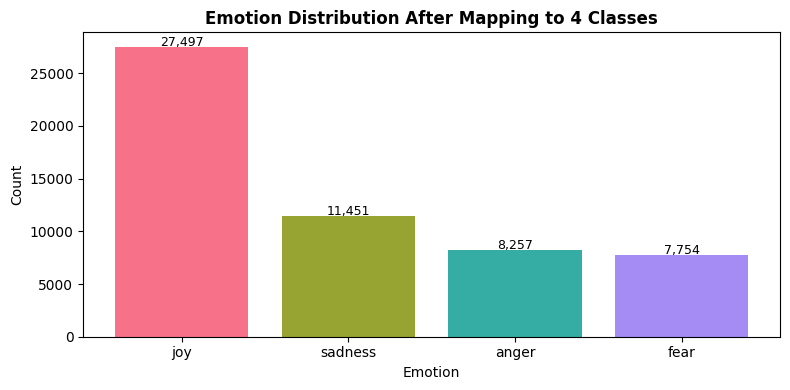

In [7]:
KEEP_EMOTIONS = ['sadness', 'joy', 'anger', 'fear']

counts = raw_mapped['emotion'].value_counts()

plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values,
               color=sns.color_palette('husl', 4))
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{val:,}', ha='center', fontsize=9)
plt.title('Emotion Distribution After Mapping to 4 Classes', fontweight='bold')
plt.xlabel('Emotion'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

## Step 6 - Extract Responses & Clean

In [8]:
def extract_customer_response(text):
    if not isinstance(text, str):
        return ''
    match = re.search(r'Customer\s*:(.*?)(?:\nAgent\s*:|$)', text, re.IGNORECASE | re.DOTALL)
    if match:
        response = match.group(1).strip()
        response = re.sub(r'\s+', ' ', response).strip()
        return response if len(response.split()) >= 2 else ''
    return ''

full_df = pd.DataFrame({
    'input'   : raw_mapped['Situation'].astype(str).str.strip(),
    'emotion' : raw_mapped['emotion'].astype(str).str.strip(),
    'response': raw_mapped['empathetic_dialogues'].apply(extract_customer_response),
})

# Filter empty rows
full_df = full_df[
    (full_df['input'].str.split().str.len()    >= 2) &
    (full_df['response'].str.split().str.len() >= 2)
].reset_index(drop=True)

print(f'Usable rows: {len(full_df):,}')
print(f'\nEmotion distribution:')
print(full_df['emotion'].value_counts().to_string())

print('\nSample pairs:')
for _, row in full_df.sample(3, random_state=42).iterrows():
    print(f'\n  Emotion : {row["emotion"]}')
    print(f'  Input   : {row["input"][:80]}')
    print(f'  Response: {row["response"][:80]}')

Usable rows: 54,634

Emotion distribution:
emotion
joy        27330
sadness    11389
anger       8214
fear        7701

Sample pairs:

  Emotion : fear
  Input   : When I was a kid, I watched Psycho at a sleepover on Halloween.  I avoided the s
  Response: I actually avoided the shower for days! lol

  Emotion : fear
  Input   : My wife talked me into bungee jumping a couple weeks ago!  It was insane and I w
  Response: I am afraid of height to, so you can imagine how I was feeling!

  Emotion : joy
  Input   : My friends and I were relaxing and swimming at a lake last weekend. My friend be
  Response: I won of course! The guy was no match for my swimming speed!


In [9]:
# Oversample sadness, anger, fear to balance against joy
max_count = full_df['emotion'].value_counts().max()  # 27,330

balanced_parts = []
for emotion in KEEP_EMOTIONS:
    subset = full_df[full_df['emotion'] == emotion]
    balanced_parts.append(
        subset.sample(max_count, replace=True, random_state=SEED)
    )

full_df = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f'Balanced rows: {len(full_df):,}')
print(full_df['emotion'].value_counts().to_string())

Balanced rows: 109,320
emotion
sadness    27330
joy        27330
fear       27330
anger      27330


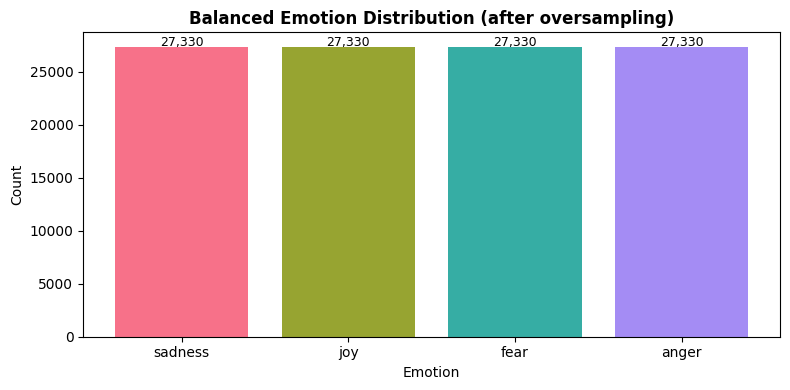

In [10]:
# Visualise
plt.figure(figsize=(8, 4))
counts = full_df['emotion'].value_counts()
bars = plt.bar(counts.index, counts.values,
               color=sns.color_palette('husl', 4))
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
             f'{val:,}', ha='center', fontsize=9)
plt.title('Balanced Emotion Distribution (after oversampling)', fontweight='bold')
plt.xlabel('Emotion'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

## Step 7 - Train/Val/ Test Split

In [11]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(full_df, test_size=0.2, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True).rename(columns={'emotion': 'context'})
val_df   = val_df.reset_index(drop=True).rename(columns={'emotion': 'context'})
test_df  = test_df.reset_index(drop=True).rename(columns={'emotion': 'context'})

train_pairs = train_df.copy()
val_pairs   = val_df.copy()
test_pairs  = test_df.copy()

train_pairs['input_len'] = train_pairs['input'].str.split().str.len()
train_pairs['resp_len']  = train_pairs['response'].str.split().str.len()

print(f'  Train : {len(train_pairs):,}')
print(f'  Val   : {len(val_pairs):,}')
print(f'  Test  : {len(test_pairs):,}')

  Train : 87,456
  Val   : 10,932
  Test  : 10,932


## Step 8 - Clean & Filter Pairs

In [12]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.replace('_comma_', ',')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'<[^>]+>', '', text)
    return text

def similarity_ratio(str1, str2):
    words1 = set(str1.lower().split())
    words2 = set(str2.lower().split())
    if not words1 or not words2:
        return 0
    return len(words1 & words2) / max(len(words1), len(words2))

def filter_pairs(df, min_words=2, sim_threshold=0.5):
    df = df.copy()
    df['input']    = df['input'].apply(clean_text)
    df['response'] = df['response'].apply(clean_text)
    df = df[
        (df['input'].str.split().str.len()    >= min_words) &
        (df['response'].str.split().str.len() >= 5) &          # response at least 5 words
        (df['input'].str.strip() != df['response'].str.strip()) # not identical
    ]
    # Remove near-duplicate pairs
    mask = df.apply(
        lambda r: similarity_ratio(r['input'], r['response']) < sim_threshold, axis=1
    )
    return df[mask].reset_index(drop=True)

train_clean = filter_pairs(train_pairs)
val_clean   = filter_pairs(val_pairs)
test_clean  = filter_pairs(test_pairs)

print(f'After cleaning:')
print(f'  Train : {len(train_clean):,}')
print(f'  Val   : {len(val_clean):,}')
print(f'  Test  : {len(test_clean):,}')

print('\nSample cleaned pair:')
sample = train_clean.sample(1, random_state=1).iloc[0]
print(f'  Emotion : {sample["context"]}')
print(f'  Input   : {sample["input"]}')
print(f'  Response: {sample["response"]}')

After cleaning:
  Train : 65,177
  Val   : 8,151
  Test  : 8,104

Sample cleaned pair:
  Emotion : joy
  Input   : My transmission went out in my car. My dad loaned me $500 to get it fixed.
  Response: It's still a work in progress, but we tested the transmission before we put it in. It works wonderfully and came out of a car that only has 90,000 miles on it, versus mine that has 200,000. I would like to get a new car, but I don't want to take on another payment until my house is paid off.


## Step 9 - EDA: Length Distribution & Sample Quality

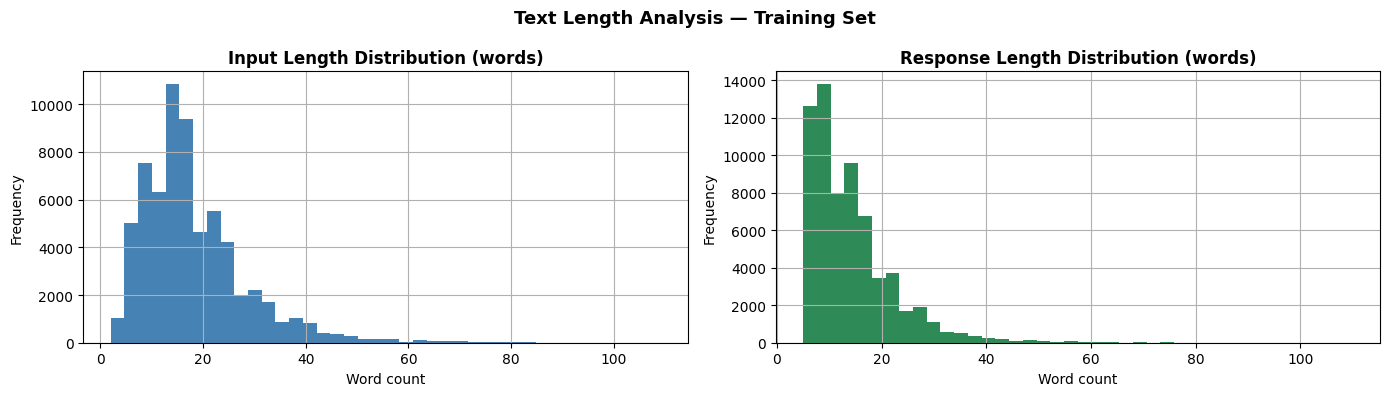


Length stats:
  Avg input length   : 18.3 words
  Avg response length: 14.1 words

Emotion coverage (train):
context
sadness    16371
fear       16294
anger      16285
joy        16227


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_clean['input'].str.split().str.len().hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Input Length Distribution (words)', fontweight='bold')
axes[0].set_xlabel('Word count'); axes[0].set_ylabel('Frequency')

train_clean['response'].str.split().str.len().hist(bins=40, ax=axes[1], color='seagreen')
axes[1].set_title('Response Length Distribution (words)', fontweight='bold')
axes[1].set_xlabel('Word count'); axes[1].set_ylabel('Frequency')

plt.suptitle('Text Length Analysis — Training Set', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nLength stats:')
print(f'  Avg input length   : {train_clean["input"].str.split().str.len().mean():.1f} words')
print(f'  Avg response length: {train_clean["response"].str.split().str.len().mean():.1f} words')
print(f'\nEmotion coverage (train):')
print(train_clean["context"].value_counts().to_string())

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Analyzing token lengths on training set...

=== INPUT (user message + emotion prefix) ===
  Min    : 10
  Max    : 135
  Mean   : 30.8
  Median : 28.0
  95th % : 56.0
  99th % : 76.0

=== TARGET (empathetic response) ===
  Min    : 6
  Max    : 153
  Mean   : 19.5
  Median : 17.0
  95th % : 39.0
  99th % : 59.0

=== % of samples covered by each MAX_LEN setting ===
  Cap  64 → Input coverage: 97.5%  |  Target coverage: 99.3%
  Cap 128 → Input coverage: 100.0%  |  Target coverage: 100.0%
  Cap 256 → Input coverage: 100.0%  |  Target coverage: 100.0%


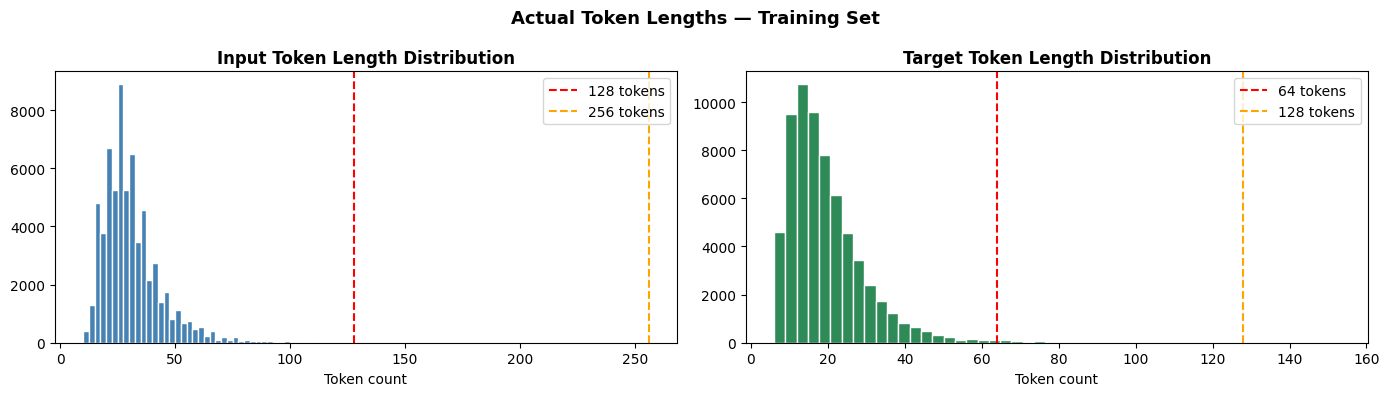

In [14]:
# ── Analyze actual lengths in the dataset ────────────────────────────────────
temp_tokenizer = T5TokenizerFast.from_pretrained('t5-small')

# Define format_input here temporarily for analysis
def format_input(emotion, text):
    return f'empathize emotion {emotion}: {text}'

def get_token_lengths(df):
    input_tokens  = []
    target_tokens = []

    for _, row in df.iterrows():
        formatted = format_input(row['context'], row['input'])
        inp_len   = len(temp_tokenizer.encode(formatted))
        tgt_len   = len(temp_tokenizer.encode(row['response']))
        input_tokens.append(inp_len)
        target_tokens.append(tgt_len)

    return input_tokens, target_tokens

print('Analyzing token lengths on training set...')
input_lens, target_lens = get_token_lengths(train_clean)

input_lens  = np.array(input_lens)
target_lens = np.array(target_lens)

print('\n=== INPUT (user message + emotion prefix) ===')
print(f'  Min    : {input_lens.min()}')
print(f'  Max    : {input_lens.max()}')
print(f'  Mean   : {input_lens.mean():.1f}')
print(f'  Median : {np.median(input_lens):.1f}')
print(f'  95th % : {np.percentile(input_lens, 95):.1f}')
print(f'  99th % : {np.percentile(input_lens, 99):.1f}')

print('\n=== TARGET (empathetic response) ===')
print(f'  Min    : {target_lens.min()}')
print(f'  Max    : {target_lens.max()}')
print(f'  Mean   : {target_lens.mean():.1f}')
print(f'  Median : {np.median(target_lens):.1f}')
print(f'  95th % : {np.percentile(target_lens, 95):.1f}')
print(f'  99th % : {np.percentile(target_lens, 99):.1f}')

print('\n=== % of samples covered by each MAX_LEN setting ===')
for cap in [64, 128, 256]:
    inp_cov = (input_lens  <= cap).mean() * 100
    tgt_cov = (target_lens <= cap).mean() * 100
    print(f'  Cap {cap:3d} → Input coverage: {inp_cov:.1f}%  |  Target coverage: {tgt_cov:.1f}%')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(input_lens,  bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(128, color='red',    linestyle='--', label='128 tokens')
axes[0].axvline(256, color='orange', linestyle='--', label='256 tokens')
axes[0].set_title('Input Token Length Distribution',  fontweight='bold')
axes[0].set_xlabel('Token count'); axes[0].legend()

axes[1].hist(target_lens, bins=50, color='seagreen', edgecolor='white')
axes[1].axvline(64,  color='red',    linestyle='--', label='64 tokens')
axes[1].axvline(128, color='orange', linestyle='--', label='128 tokens')
axes[1].set_title('Target Token Length Distribution', fontweight='bold')
axes[1].set_xlabel('Token count'); axes[1].legend()

plt.suptitle('Actual Token Lengths — Training Set', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
# Tighten similarity filter from 0.5 → 0.4
train_clean = train_clean[
    train_clean.apply(
        lambda r: similarity_ratio(r['input'], r['response']) < 0.4, axis=1
    )
].reset_index(drop=True)

val_clean = val_clean[
    val_clean.apply(
        lambda r: similarity_ratio(r['input'], r['response']) < 0.4, axis=1
    )
].reset_index(drop=True)

test_clean = test_clean[
    test_clean.apply(
        lambda r: similarity_ratio(r['input'], r['response']) < 0.4, axis=1
    )
].reset_index(drop=True)

print(f'After tightening similarity filter (< 0.4):')
print(f'  Train : {len(train_clean):,}')
print(f'  Val   : {len(val_clean):,}')
print(f'  Test  : {len(test_clean):,}')

# Verify — should be 0 pairs above 0.4
remaining = sum(
    1 for _, row in train_clean.iterrows()
    if similarity_ratio(row['input'], row['response']) >= 0.4
)
print(f'\nNear-paraphrase pairs remaining: {remaining}')

After tightening similarity filter (< 0.4):
  Train : 61,307
  Val   : 7,646
  Test  : 7,622

Near-paraphrase pairs remaining: 0


Step 10 — Format for T5 & Tokenize

In [16]:
# Check how many near-paraphrase pairs remain in train_clean
similar_count = sum(
    1 for _, row in train_clean.iterrows()
    if similarity_ratio(row['input'], row['response']) > 0.4
)
total = len(train_clean)
print(f'Near-paraphrase pairs remaining : {similar_count:,} / {total:,} ({similar_count/total*100:.1f}%)')

# Show some examples
print('\n=== Sample near-paraphrase pairs ===')
count = 0
for _, row in train_clean.iterrows():
    if similarity_ratio(row['input'], row['response']) > 0.4:
        print(f'\n  Emotion    : {row["context"]}')
        print(f'  Input      : {row["input"][:80]}')
        print(f'  Response   : {row["response"][:80]}')
        print(f'  Similarity : {similarity_ratio(row["input"], row["response"]):.2f}')
        count += 1
        if count == 5:
            break

Near-paraphrase pairs remaining : 0 / 61,307 (0.0%)

=== Sample near-paraphrase pairs ===


In [17]:
MODEL_NAME     = 't5-small'
MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 64

tokenizer = T5TokenizerFast.from_pretrained(MODEL_NAME)

def format_input(emotion, text):
    """Emotion prefix — now only 4 possible emotions, clean and consistent."""
    return f'empathize emotion {emotion}: {text}'

# Sanity check
print('=== T5 Input Format Examples ===')
for _, row in train_clean.sample(3, random_state=42).iterrows():
    print(f'\nFormatted : {format_input(row["context"], row["input"])[:100]}')
    print(f'Target    : {row["response"][:80]}')

=== T5 Input Format Examples ===

Formatted : empathize emotion sadness: The chain on the necklace my boyfriend gave me broke and I lost the penda
Target    : I only noticed once I got home from work. It most have broke somewhere on my wal

Formatted : empathize emotion joy: I used to go to this Starbucks with horrible service. So I was always ready w
Target    : They never learn, do they ?

Formatted : empathize emotion fear: I'm hosting thanksgiving for the very first time this year. Some of my famil
Target    : really, that is awesome. you will have fun


In [18]:
from datasets import Dataset as HFDataset

def tokenize_pairs(df):
    inputs  = [format_input(row['context'], row['input']) for _, row in df.iterrows()]
    targets = [row['response']                             for _, row in df.iterrows()]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LEN,
        padding='max_length',
        truncation=True,
    )
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LEN,
        padding='max_length',
        truncation=True,
    )
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels['input_ids']
    ]
    model_inputs['labels'] = label_ids
    return model_inputs

def df_to_hf_dataset(df):
    tokenized = tokenize_pairs(df)
    return HFDataset.from_dict({
        'input_ids'     : tokenized['input_ids'],
        'attention_mask': tokenized['attention_mask'],
        'labels'        : tokenized['labels'],
    })

print('Tokenizing train...')
tok_train = df_to_hf_dataset(train_clean)
print('Tokenizing val...')
tok_val   = df_to_hf_dataset(val_clean)
print('Tokenizing test...')
tok_test  = df_to_hf_dataset(test_clean)

tok_train.set_format(type='torch')
tok_val.set_format(type='torch')
tok_test.set_format(type='torch')

print(f'\n✅ Tokenization complete')
print(f'   Train : {len(tok_train):,}')
print(f'   Val   : {len(tok_val):,}')
print(f'   Test  : {len(tok_test):,}')

Tokenizing train...
Tokenizing val...
Tokenizing test...

✅ Tokenization complete
   Train : 61,307
   Val   : 7,646
   Test  : 7,622


## Step 11 - Evaluation Metrics

In [19]:
import sacrebleu
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

scorer_rouge = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1).astype(np.int32)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    filtered = [(p, l) for p, l in zip(decoded_preds, decoded_labels) if p and l]
    if not filtered:
        return {'bleu': 0, 'rouge1': 0, 'rouge2': 0, 'rougeL': 0,
                'bertscore_p': 0, 'bertscore_r': 0, 'bertscore_f1': 0}
    decoded_preds, decoded_labels = zip(*filtered)
    decoded_preds  = list(decoded_preds)
    decoded_labels = list(decoded_labels)

    bleu = sacrebleu.corpus_bleu(decoded_preds, [decoded_labels]).score

    rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
    for pred, label in zip(decoded_preds, decoded_labels):
        scores = scorer_rouge.score(label, pred)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    P, R, F1 = bert_score_fn(
        decoded_preds, decoded_labels,
        lang='en',
        model_type='distilbert-base-uncased',
        verbose=False,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        batch_size=64,
    )

    return {
        'bleu'        : round(bleu, 4),
        'rouge1'      : round(np.mean(rouge1_scores), 4),
        'rouge2'      : round(np.mean(rouge2_scores), 4),
        'rougeL'      : round(np.mean(rougeL_scores), 4),
        'bertscore_p' : round(P.mean().item(), 4),
        'bertscore_r' : round(R.mean().item(), 4),
        'bertscore_f1': round(F1.mean().item(), 4),
    }

print('✅ Metrics ready')

✅ Metrics ready


## Step 12 - Load T5 & Phase 1 Training

In [20]:
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model           : {MODEL_NAME}')
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')
print(f'Model size      : ~{total*4/1e6:.0f} MB')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model           : t5-small
Total params    : 60,506,624
Trainable params: 60,506,624
Model size      : ~242 MB


In [21]:
print(torch.cuda.is_available())
print(device)

True
cuda


In [22]:
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'Device         : {device}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')

CUDA available : True
Device         : cuda
GPU            : Tesla T4


In [23]:
# Freeze encoder, train decoder only
for name, param in model.named_parameters():
    if 'encoder' in name:
        param.requires_grad = False

p1_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 trainable params (decoder only): {p1_trainable:,}')

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

phase1_args = Seq2SeqTrainingArguments(
    output_dir                  = './t5_empathetic_phase1',
    num_train_epochs            = 2,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 5e-4,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'rougeL',
    greater_is_better           = True,
    logging_steps               = 200,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    seed                        = SEED,
)

trainer_p1 = Seq2SeqTrainer(
    model            = model,
    args             = phase1_args,
    train_dataset    = tok_train,
    eval_dataset     = tok_val,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

print('Starting Phase 1 (decoder warmup)...')
trainer_p1.train()
print('✅ Phase 1 complete')

Phase 1 trainable params (decoder only): 41,625,344
Starting Phase 1 (decoder warmup)...


Epoch,Training Loss,Validation Loss,Bleu,Rouge1,Rouge2,Rougel,Bertscore P,Bertscore R,Bertscore F1
1,3.116630,2.870378,1.935500,0.146500,0.028800,0.134100,0.718200,0.688700,0.702700
2,2.952774,2.775012,2.138600,0.160300,0.031800,0.142500,0.719500,0.695600,0.706900


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


✅ Phase 1 complete


## Step 13 - Phase 2 Training (Full Fine-Tuning)

In [24]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

p2_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable params (all): {p2_trainable:,}')

phase2_args = Seq2SeqTrainingArguments(
    output_dir                  = './t5_empathetic_phase2',
    num_train_epochs            = 8,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 3e-4,
    warmup_steps                = 300,
    weight_decay                = 0.01,
    lr_scheduler_type           = 'cosine',
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'rougeL',
    greater_is_better           = True,
    logging_steps               = 200,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    seed                        = SEED,
    generation_num_beams        = 4,
)

trainer = Seq2SeqTrainer(
    model            = model,
    args             = phase2_args,
    train_dataset    = tok_train,
    eval_dataset     = tok_val,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting Phase 2 (full fine-tuning)...')
train_result = trainer.train()

print('\n=== Training Summary ===')
print(f"  Steps        : {train_result.global_step}")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  Runtime      : {train_result.metrics['train_runtime']:.1f}s")

Phase 2 trainable params (all): 60,506,624
Starting Phase 2 (full fine-tuning)...


Epoch,Training Loss,Validation Loss,Bleu,Rouge1,Rouge2,Rougel,Bertscore P,Bertscore R,Bertscore F1
1,2.790810,2.617329,2.474000,0.148100,0.034200,0.135400,0.712100,0.693700,0.702300
2,2.644047,2.450627,3.241700,0.172300,0.046400,0.152600,0.724800,0.711300,0.717500
3,2.461937,2.311398,3.443700,0.177000,0.051100,0.157200,0.724500,0.713500,0.718400
4,2.331584,2.198383,4.037100,0.183200,0.056400,0.163200,0.726900,0.714600,0.720200
5,2.228999,2.113257,4.709200,0.190100,0.063300,0.170200,0.729500,0.718400,0.723400
6,2.188842,2.060135,5.277100,0.194100,0.068400,0.174300,0.731800,0.720300,0.725500
7,2.126292,2.038819,5.432500,0.194900,0.070200,0.175000,0.731600,0.720400,0.725400
8,2.099417,2.035633,5.347200,0.194000,0.069600,0.173900,0.731600,0.720200,0.725300


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



=== Training Summary ===
  Steps        : 30656
  Training loss: 2.3922
  Runtime      : 4911.1s


## Step 14 - Evaluation on Test Set

In [25]:
test_results = trainer.evaluate(tok_test)

print('\n' + '='*55)
print('         TEST SET EVALUATION RESULTS')
print('='*55)
print(f"  BLEU          : {test_results['eval_bleu']:.4f}")
print(f"  ROUGE-1       : {test_results['eval_rouge1']:.4f}")
print(f"  ROUGE-2       : {test_results['eval_rouge2']:.4f}")
print(f"  ROUGE-L       : {test_results['eval_rougeL']:.4f}")
print(f"  BERTScore P   : {test_results['eval_bertscore_p']:.4f}")
print(f"  BERTScore R   : {test_results['eval_bertscore_r']:.4f}")
print(f"  BERTScore F1  : {test_results['eval_bertscore_f1']:.4f}")
print('='*55)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



         TEST SET EVALUATION RESULTS
  BLEU          : 5.1184
  ROUGE-1       : 0.1909
  ROUGE-2       : 0.0644
  ROUGE-L       : 0.1708
  BERTScore P   : 0.7312
  BERTScore R   : 0.7199
  BERTScore F1  : 0.7250


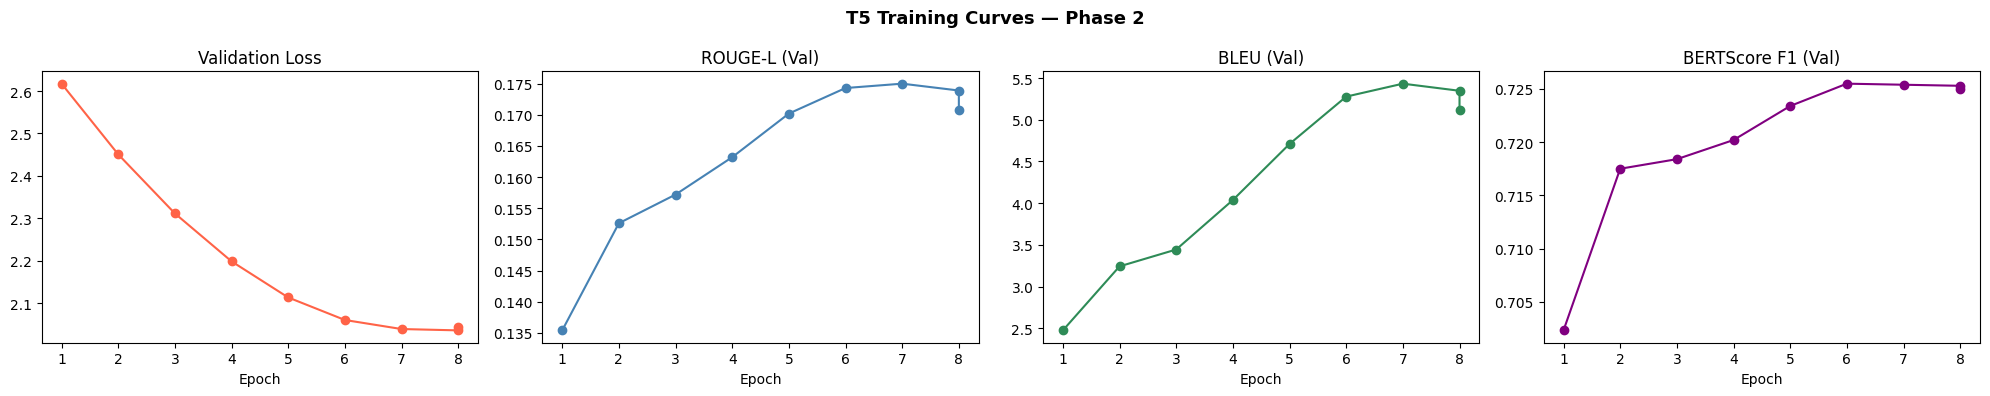

In [26]:
# Training curves
log_history = trainer.state.log_history
eval_logs   = [x for x in log_history if 'eval_loss' in x]

if eval_logs:
    epochs  = [x['epoch']                    for x in eval_logs]
    ev_loss = [x['eval_loss']                for x in eval_logs]
    rougeL  = [x.get('eval_rougeL', 0)       for x in eval_logs]
    bleu    = [x.get('eval_bleu', 0)         for x in eval_logs]
    bert_f1 = [x.get('eval_bertscore_f1', 0) for x in eval_logs]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    axes[0].plot(epochs, ev_loss, 'o-', color='tomato')
    axes[0].set_title('Validation Loss');    axes[0].set_xlabel('Epoch')
    axes[1].plot(epochs, rougeL, 'o-', color='steelblue')
    axes[1].set_title('ROUGE-L (Val)');      axes[1].set_xlabel('Epoch')
    axes[2].plot(epochs, bleu, 'o-', color='seagreen')
    axes[2].set_title('BLEU (Val)');         axes[2].set_xlabel('Epoch')
    axes[3].plot(epochs, bert_f1, 'o-', color='purple')
    axes[3].set_title('BERTScore F1 (Val)'); axes[3].set_xlabel('Epoch')
    plt.suptitle('T5 Training Curves — Phase 2', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Step 15 - Save Model

In [27]:
# Zip and download
import shutil
from google.colab import files

LOCAL_SAVE = './t5_empathetic_4class'
trainer.save_model(LOCAL_SAVE)
tokenizer.save_pretrained(LOCAL_SAVE)

shutil.make_archive('t5_empathetic_4class', 'zip', LOCAL_SAVE)
print('✅ Zipped. Downloading...')
files.download('t5_empathetic_4class.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Zipped. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 16 - Inference Demo

In [30]:
# Load saved model and tokenizer directly
from transformers import T5ForConditionalGeneration, T5TokenizerFast

gen_tokenizer = T5TokenizerFast.from_pretrained(LOCAL_SAVE)
gen_model     = T5ForConditionalGeneration.from_pretrained(LOCAL_SAVE).to(device)
gen_model.eval()

def generate_response(user_message, detected_emotion, num_beams=4, max_new_tokens=60):
    prompt = format_input(detected_emotion, user_message)
    inputs = gen_tokenizer(
        prompt,
        return_tensors='pt',
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding=True,
    ).to(device)

    input_token_ids = inputs['input_ids'][0].tolist()

    with torch.no_grad():
        outputs = gen_model.generate(
            input_ids              = inputs['input_ids'],
            attention_mask         = inputs['attention_mask'],
            max_new_tokens         = 60,
            num_beams              = 5,
            early_stopping         = True,
            no_repeat_ngram_size   = 4,
            length_penalty         = 2.0,
            repetition_penalty     = 3.5,    # ← stronger penalty
            encoder_no_repeat_ngram_size = 4, # ← prevents copying input ngrams
            do_sample              = True,
            temperature            = 0.8,
            top_p                  = 0.92,
        )

    response = gen_tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Fallback if response still too similar to input
    def similarity(a, b):
        w1, w2 = set(a.lower().split()), set(b.lower().split())
        return len(w1 & w2) / max(len(w1), len(w2)) if w1 and w2 else 0

    if similarity(response, user_message) > 0.5:
        with torch.no_grad():
            outputs = gen_model.generate(
                input_ids              = inputs['input_ids'],
                attention_mask         = inputs['attention_mask'],
                max_new_tokens         = 60,
                do_sample              = True,
                temperature            = 1.3,
                top_p                  = 0.95,
                top_k                  = 50,
                repetition_penalty     = 4.0,
                encoder_no_repeat_ngram_size = 4,
            )
        response = gen_tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response

# Rerun test cases
test_cases = [
    ("I feel so overwhelmed and don't know what to do anymore.", 'fear'),
    ("I just got rejected from the job I really wanted.",        'sadness'),
    ("My dog passed away yesterday, I can't stop crying.",       'sadness'),
    ("I feel so alone, nobody seems to understand me.",          'sadness'),
    ("I just got promoted! I worked so hard for this.",          'joy'),
    ("I'm really angry at my friend for betraying my trust.",    'anger'),
    ("I am so happy today, everything is going great!",          'joy'),
    ("I'm scared about what's going to happen next.",            'fear'),
]

print('=== Empathetic Response Generation Demo (Fixed) ===\n')
for user_msg, emotion in test_cases:
    response = generate_response(user_msg, emotion)
    print(f'Emotion  : {emotion.upper()}')
    print(f'User     : {user_msg}')
    print(f'Chatbot  : {response}')
    print('-' * 70)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

=== Empathetic Response Generation Demo (Fixed) ===

Emotion  : FEAR
User     : I feel so overwhelmed and don't know what to do anymore.
Chatbot  : I'm sorry to hear that. What are you going to do with it?
----------------------------------------------------------------------
Emotion  : SADNESS
User     : I just got rejected from the job I really wanted.
Chatbot  : I'm sorry to hear that. What did you get?
----------------------------------------------------------------------
Emotion  : SADNESS
User     : My dog passed away yesterday, I can't stop crying.
Chatbot  : Oh no! I'm so sorry to hear that. How old was he?
----------------------------------------------------------------------
Emotion  : SADNESS
User     : I feel so alone, nobody seems to understand me.
Chatbot  : I'm sorry to hear that. How do you feel about it?
----------------------------------------------------------------------
Emotion  : JOY
User     : I just got promoted! I worked so hard for this.
Chatbot  : That's grea